## Parellelization in LangGraph

In LangGraph, nodes typically execute in a sequence defined by edges, but when tasks don't depend on each other's outputs, you can run them in parellel. This is achieved by
- Defining multiple nodes that can operate independently.
- Connecting them to a common starting point (e.g START or another node).
- Merging their outputs into a downstream node if needed

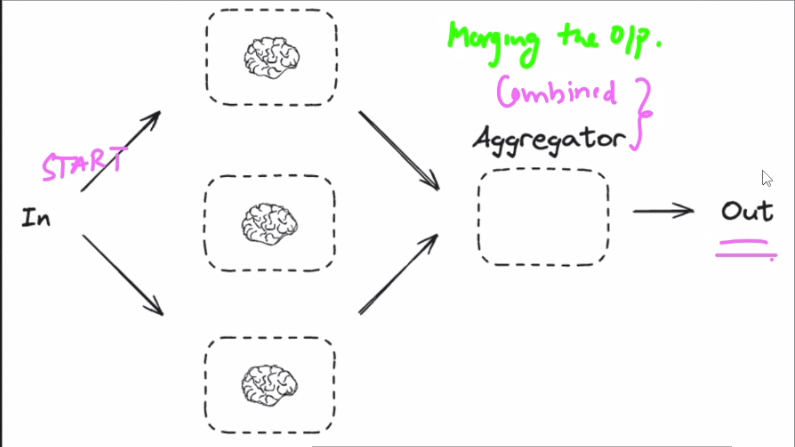

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_nvidia_ai_endpoints import ChatNVIDIA

os.environ['NVIDIA_API_KEY'] = os.getenv('NVIDIA_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Parellelization"

from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(
  model="openai/gpt-oss-20b",
  api_key=os.getenv('NVIDIA_API_KEY'), 
  temperature=1,
  top_p=1,
  max_completion_tokens=4096,
)

In [2]:
from dataclasses import dataclass
from typing import Optional
from langchain_core.messages import SystemMessage, HumanMessage

## System Prompt
SYSTEM_PROMPT = """You are a creative story writer assistant. 
Your job is to help craft engaging, vivid, and imaginative stories.
Always be descriptive, creative, and consistent with the story elements provided."""

@dataclass
class State:
    topic: str
    characters: Optional[str] = None
    settings: Optional[str] = None
    premises: Optional[str] = None
    story_intro: Optional[str] = None

## Nodes
def generate_character(state: State):
    """Generate Character Description"""
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"Create two character names and brief traits for a story about {state.topic}")
    ]
    msg = llm.invoke(messages)
    return {"characters": msg.content}

def generate_settings(state: State):
    """Generate a story setting"""
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"Describe a vivid setting for a story about {state.topic}")
    ]
    msg = llm.invoke(messages)
    return {"settings": msg.content}

def generate_premise(state: State):
    """Generate a plot premise"""
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"Write a one-sentence plot premise for a story about {state.topic}")
    ]
    msg = llm.invoke(messages)
    return {"premises": msg.content}

def combine_element(state: State):
    """Combine characters, settings, premises into an intro"""
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=
            f"Write a short story introduction using these elements:\n"
            f"Characters: {state.characters}\n"
            f"Settings: {state.settings}\n"
            f"Premise: {state.premises}"
        )
    ]
    msg = llm.invoke(messages)
    return {"story_intro": msg.content}

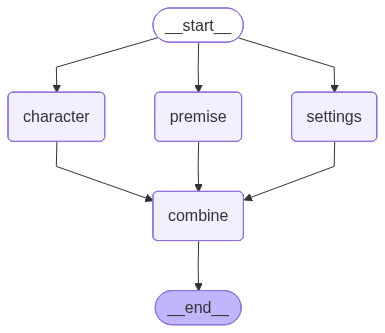

In [5]:
## Build the Graph
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

memory = MemorySaver()
builder = StateGraph(State)

builder.add_node("character", generate_character)
builder.add_node("settings", generate_settings)
builder.add_node("premise", generate_premise)
builder.add_node("combine", combine_element)


## Adding Edges
builder.add_edge(START, "character")
builder.add_edge(START, "settings")
builder.add_edge(START, "premise")
builder.add_edge("character", "combine")
builder.add_edge("settings", "combine")
builder.add_edge("premise", "combine")
builder.add_edge("combine", END)

graph = builder.compile(checkpointer= memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
def run_story_graph(topic: str, thread_id: int = 1, verbose: bool = False):
    """Invoke the story graph and return the result"""
    
    config = {"configurable": {"thread_id": thread_id}}
    query = {"topic": topic}
    
    result = graph.invoke(query, config=config)
    
    if verbose:
        print("=" * 50)
        print(f"📖 Topic      : {topic}")
        print("=" * 50)
        print(f"🧑 Characters :\n{result['characters']}\n")
        print(f"🌍 Settings   :\n{result['settings']}\n")
        print(f"💡 Premise    :\n{result['premises']}\n")
        print(f"✍️  Story Intro :\n{result['story_intro']}")
        print("=" * 50)
    else:
        print(result['story_intro'])
    
    return result


## Run — Simple
# run_story_graph("Time Travel")

## Run — Verbose (see all state fields)
run_story_graph("Time Travel", thread_id=2, verbose=True)

📖 Topic      : Time Travel
🧑 Characters :
**Character 1 – “Ariadne Vale”**  
- **Age/Occupation:** 28‑year‑old chronomancer and quantum physicist in a hidden research lab.  
- **Appearance:** Long silver‑lined hair, always wears a pocket watch with looping gears, an iridescent lab coat that subtly shifts with timelines.  
- **Personality:** Curious to a fault, she has a forgiving optimism that masks a deep tendency to over‑deepen her own timelines. Values knowledge above all, often ignoring warning signs in her eagerness to uncover the next paradox.  
- **Motivation:** To find and fix the original “Great Temporal Commute” that impossible events are bleeding from—a sequence where an accidental future‑flood blinds her own era.  

**Character 2 – “Cassian Thorne”**  
- **Age/Occupation:** 42‑year‑old archivist of the Temporal Bureau; a recruiter of “History’s Custodians.”  
- **Appearance:** Tall, with a gravely tattooed map of the Earth’s epochs on his forearm; favors a trench coat lined

{'topic': 'Time Travel',
 'characters': '**Character 1 – “Ariadne Vale”**  \n- **Age/Occupation:** 28‑year‑old chronomancer and quantum physicist in a hidden research lab.  \n- **Appearance:** Long silver‑lined hair, always wears a pocket watch with looping gears, an iridescent lab coat that subtly shifts with timelines.  \n- **Personality:** Curious to a fault, she has a forgiving optimism that masks a deep tendency to over‑deepen her own timelines. Values knowledge above all, often ignoring warning signs in her eagerness to uncover the next paradox.  \n- **Motivation:** To find and fix the original “Great Temporal Commute” that impossible events are bleeding from—a sequence where an accidental future‑flood blinds her own era.  \n\n**Character 2 – “Cassian Thorne”**  \n- **Age/Occupation:** 42‑year‑old archivist of the Temporal Bureau; a recruiter of “History’s Custodians.”  \n- **Appearance:** Tall, with a gravely tattooed map of the Earth’s epochs on his forearm; favors a trench coa

### Key Benefits
- Speed: Reduces total execution time by running tasks concurrently.
- Scalibility: Handles larger workflows efficiently.
- Modularity: Keeps the graph structure clean and reusable.

### Key Takeaways
- When to Parellize: Use it for independent tasks(e.g. Generating multiple outputs, checking seperate inputs.)
- Merging: Downstream nodes can aggregate parellel results.
- LangGraph Support: The framework naturally supports this by waiting for all required inputs before proceeding